In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
data_path = Path.home() / "BEP-beau/BEP/data" / "mohembo_daily_water_discharge_data.csv"
data = pd.read_csv(data_path, index_col='date', parse_dates=True, dayfirst=True)
data_daily = data.resample('D').interpolate()
data_daily.columns = ['Discharge (m^3/s)']
data_daily = data_daily[~data_daily.index.year.isin([1974, 2021])]

SSP126_daily = pd.read_csv('SSP126_daily.csv', index_col=0, parse_dates=True, names=['Date', 'SSP126'], header=0)
SSP245_daily = pd.read_csv('SSP245_daily.csv', index_col=0, parse_dates=True, names=['Date', 'SSP245'], header=0)
SSP370_daily = pd.read_csv('SSP370_daily.csv', index_col=0, parse_dates=True, names=['Date', 'SSP370'], header=0)
SSP585_daily = pd.read_csv('SSP585_daily.csv', index_col=0, parse_dates=True, names=['Date', 'SSP585'], header=0)

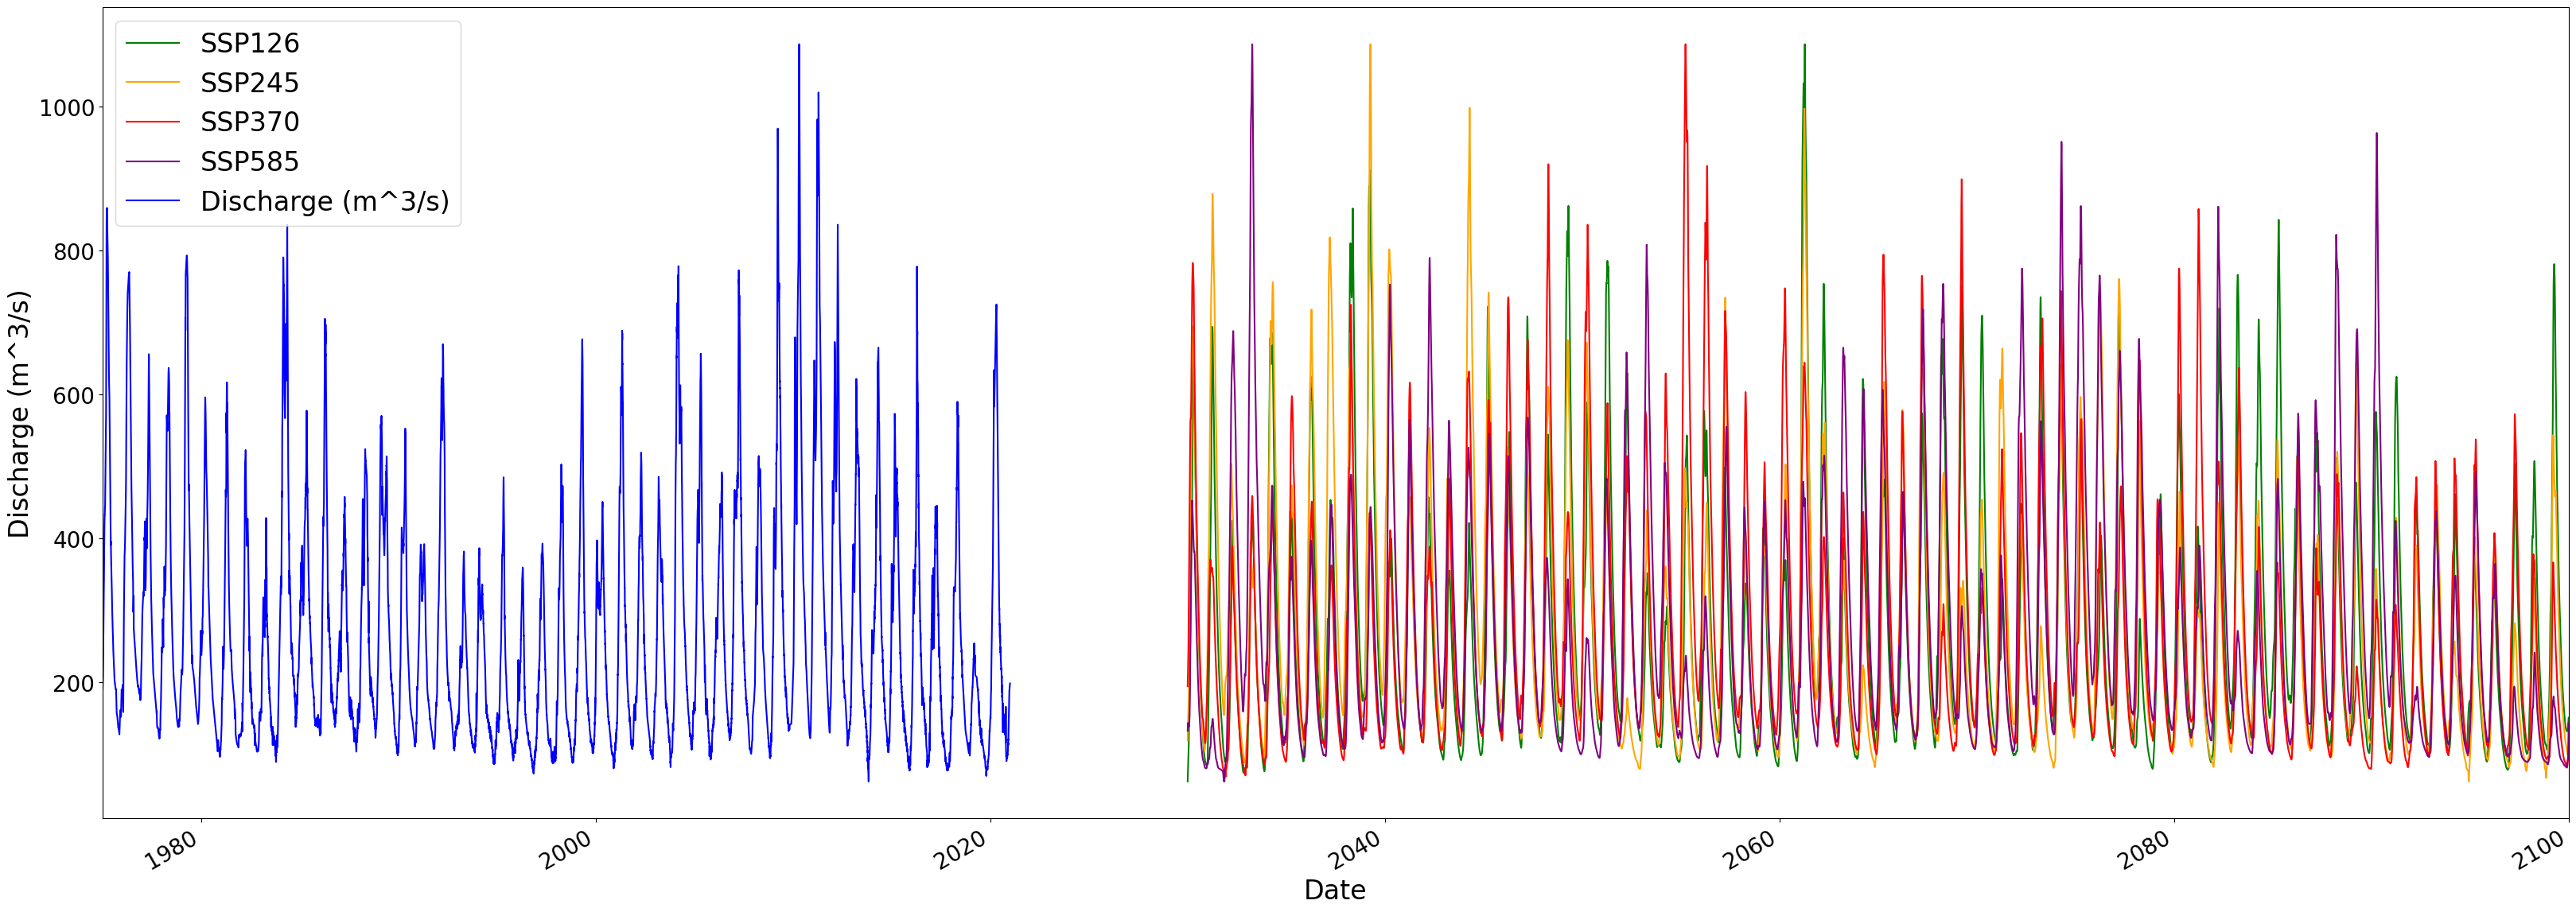

In [18]:
fig, ax = plt.subplots(figsize=(40, 15))
SSP126_daily.plot(ax=ax, color='green')
SSP245_daily.plot(ax=ax, color='orange')
SSP370_daily.plot(ax=ax, color='red')
SSP585_daily.plot(ax=ax, color='purple')
data_daily.plot(ax=ax, color='blue')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m^3/s)", fontsize=24)
plt.xlim('1975', '2100')
plt.legend(fontsize=24);

In [4]:
yearly_volume = (data_daily * 3600 * 24).resample('YE').sum() / 1e6
yearly_volume.columns = ['Yearly volume (Mm^3)']

SSP126_yearly = pd.read_csv('SSP126_yearly.csv', index_col=0, parse_dates=True, names=['Date', 'SSP126'], header=0)
SSP245_yearly = pd.read_csv('SSP245_yearly.csv', index_col=0, parse_dates=True, names=['Date', 'SSP245'], header=0)
SSP370_yearly = pd.read_csv('SSP370_yearly.csv', index_col=0, parse_dates=True, names=['Date', 'SSP370'], header=0)
SSP585_yearly = pd.read_csv('SSP585_yearly.csv', index_col=0, parse_dates=True, names=['Date', 'SSP585'], header=0)

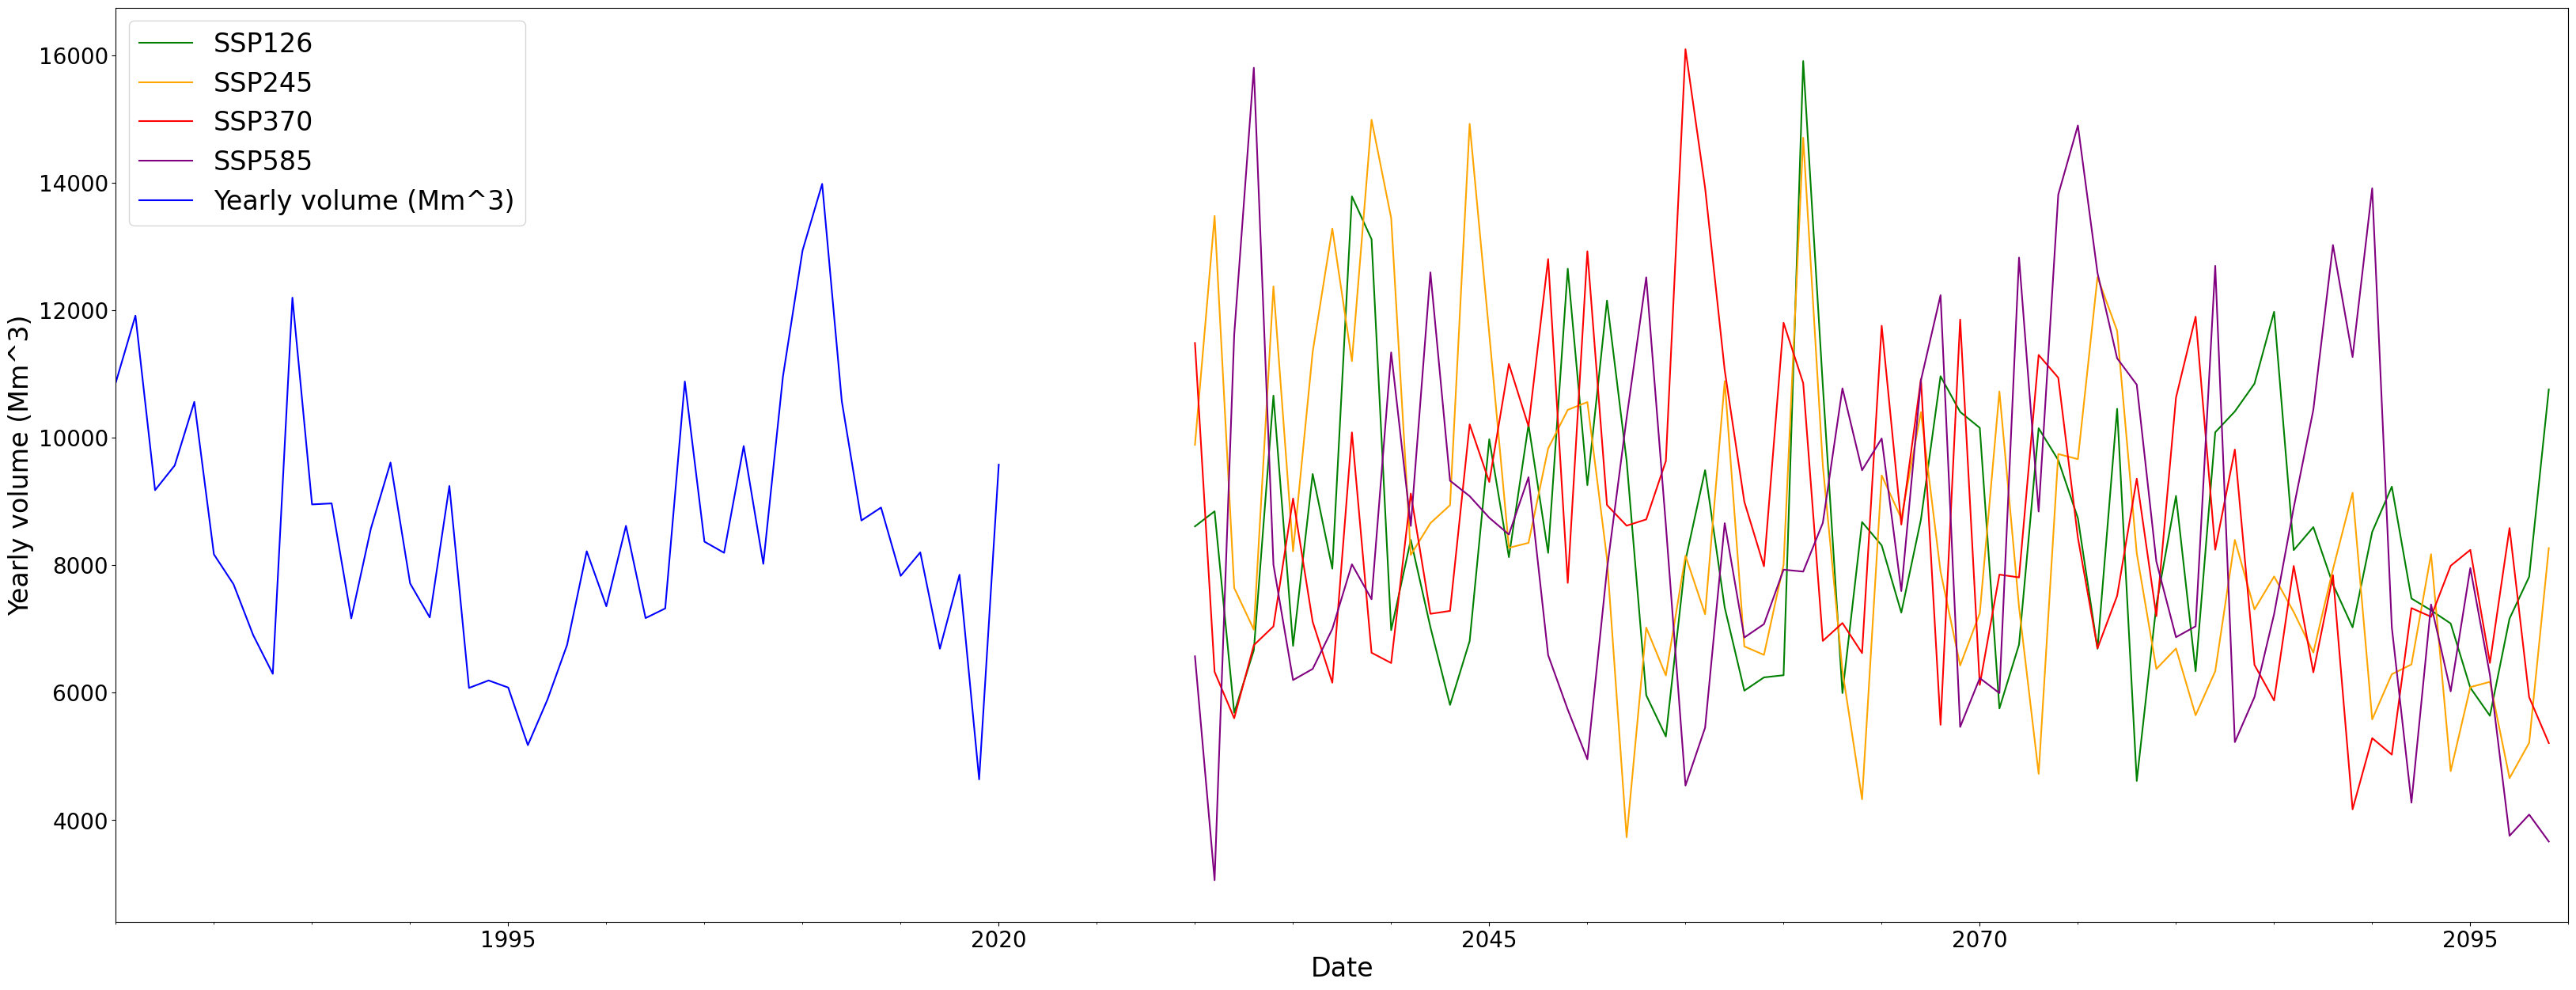

In [22]:
fig, ax = plt.subplots(figsize=(40, 15))
SSP126_yearly.plot(ax=ax, color='green')
SSP245_yearly.plot(ax=ax, color='orange')
SSP370_yearly.plot(ax=ax, color='red')
SSP585_yearly.plot(ax=ax, color='purple')
yearly_volume.plot(ax=ax, color='blue')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Yearly volume (Mm^3)", fontsize=24)
plt.xlim('1975', '2100')
plt.legend(fontsize=24);

In [6]:
def return_periods(data):
    n = len(data)
    rank = np.arange(1, n + 1)
    return_period = (n + 1) / rank
    return return_period

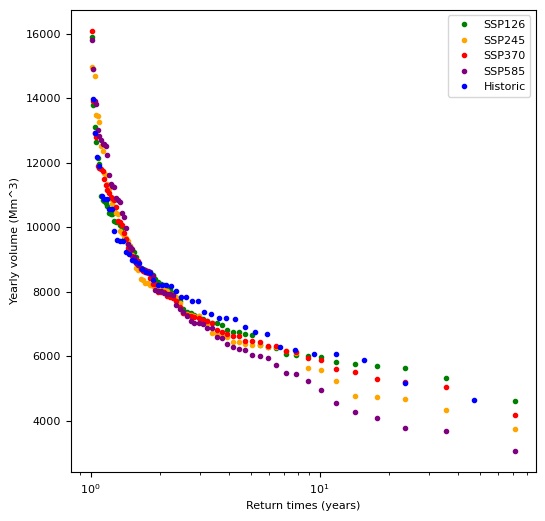

In [23]:
return_period_historic = return_periods(yearly_volume)
return_period_CMIP = return_periods(SSP126_yearly)

historic_sorted = np.sort(yearly_volume['Yearly volume (Mm^3)'])
SSP126_yearly_sorted = np.sort(SSP126_yearly['SSP126'])
SSP245_yearly_sorted = np.sort(SSP245_yearly['SSP245'])
SSP370_yearly_sorted = np.sort(SSP370_yearly['SSP370'])
SSP585_yearly_sorted = np.sort(SSP585_yearly['SSP585'])

fig, ax = plt.subplots(figsize=(6, 6))
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
ax.set_xlabel("Return times (years)", fontsize=8)
ax.set_ylabel("Yearly volume (Mm^3)", fontsize=8)
plt.xscale('log')

plt.plot(return_period_CMIP, SSP126_yearly_sorted, marker='o', linestyle='None', ms=3, label='SSP126', color='green')
plt.plot(return_period_CMIP, SSP245_yearly_sorted, marker='o', linestyle='None', ms=3, label='SSP245', color='orange')
plt.plot(return_period_CMIP, SSP370_yearly_sorted, marker='o', linestyle='None', ms=3, label='SSP370', color='red')
plt.plot(return_period_CMIP, SSP585_yearly_sorted, marker='o', linestyle='None', ms=3, label='SSP585', color='purple')
plt.plot(return_period_historic, historic_sorted, marker='o', linestyle='None', ms=3, label='Historic', color='blue')
plt.legend(fontsize=8);

In [24]:
CMIP_scenarios_yearly = [SSP126_yearly_sorted, SSP245_yearly_sorted, SSP370_yearly_sorted, SSP585_yearly_sorted]
names = ['SSP126', 'SSP245', 'SSP370', 'SSP585']
percentile15 = np.percentile(historic_sorted, 15)
percentile10 = np.percentile(historic_sorted, 10)
percentile5 = np.percentile(historic_sorted, 5)

interpolate_func_h = interp1d(historic_sorted, return_period_historic, bounds_error=False, fill_value="extrapolate")
return15_h = interpolate_func_h(percentile15)
return10_h = interpolate_func_h(percentile10)
return5_h = interpolate_func_h(percentile5)

print('Historic')
print(f'Return period 15th percentile: {return15_h:.2f}')
print(f'Return period 10th percentile: {return10_h:.2f}')
print(f'Return period 5th percentile: {return5_h:.2f}')

for i in range(len(CMIP_scenarios_yearly)):
    interpolate_func = interp1d(CMIP_scenarios_yearly[i], return_period_CMIP, bounds_error=False, fill_value="extrapolate")
    return15 = interpolate_func(percentile15)
    return10 = interpolate_func(percentile10)
    return5 = interpolate_func(percentile5)
    print(f'{names[i]}')
    print(f'Return period 15th percentile: {return15:.2f}')
    print(f'Return period 10th percentile: {return10:.2f}')
    print(f'Return period 5th percentile: {return5:.2f}')

Historic
Return period 15th percentile: 6.08
Return period 10th percentile: 8.62
Return period 5th percentile: 14.69
SSP126
Return period 15th percentile: 5.16
Return period 10th percentile: 6.87
Return period 5th percentile: 10.39
SSP245
Return period 15th percentile: 3.95
Return period 10th percentile: 7.42
Return period 5th percentile: 8.22
SSP370
Return period 15th percentile: 4.49
Return period 10th percentile: 7.58
Return period 5th percentile: 8.83
SSP585
Return period 15th percentile: 3.55
Return period 10th percentile: 4.85
Return period 5th percentile: 5.87


In [9]:
for j in range(len(CMIP_scenarios_yearly)):
    SSP_data = CMIP_scenarios_yearly[j]
    u15 = len(SSP_data[(SSP_data < percentile15) & (SSP_data > percentile10)])
    u10 = len(SSP_data[(SSP_data < percentile10) & (SSP_data > percentile5)])
    u5 = len(SSP_data[(SSP_data < percentile5)])
    print(f'{names[j]}')
    print(f'Number of years under 15th percentile: {u15}')
    print(f'Number of years under 10th percentile: {u10}')
    print(f'Number of years under 5th percentile: {u5}')

SSP126
Number of years under 15th percentile: 3
Number of years under 10th percentile: 4
Number of years under 5th percentile: 6
SSP245
Number of years under 15th percentile: 8
Number of years under 10th percentile: 1
Number of years under 5th percentile: 8
SSP370
Number of years under 15th percentile: 6
Number of years under 10th percentile: 1
Number of years under 5th percentile: 8
SSP585
Number of years under 15th percentile: 6
Number of years under 10th percentile: 2
Number of years under 5th percentile: 12


In [19]:
historic35 = yearly_volume[-35::]
u15_historic35 = len(historic35[(historic35['Yearly volume (Mm^3)'] < percentile15) & (historic35['Yearly volume (Mm^3)'] > percentile10)])
u10_historic35 = len(historic35[(historic35['Yearly volume (Mm^3)'] < percentile10) & (historic35['Yearly volume (Mm^3)'] > percentile5)])
u5_historic35 = len(historic35[(historic35['Yearly volume (Mm^3)'] < percentile5)])
print('Last historic 35 years')
print(f'Number of years under 15th percentile: {u15_historic35}')
print(f'Number of years under 10th percentile: {u10_historic35}')
print(f'Number of years under 5th percentile: {u5_historic35}')

CMIP_scenarios = [SSP126_yearly, SSP245_yearly, SSP370_yearly, SSP585_yearly]
names = ['SSP126', 'SSP245', 'SSP370', 'SSP585']
for k in range(len(CMIP_scenarios)):
    SSP_data = CMIP_scenarios[k] 
    first35 = SSP_data[0:35]
    last35 = SSP_data[-35::]
    
    u15_first35 = len(first35[(first35[names[k]] < percentile15) & (first35[names[k]] > percentile10)])
    u15_last35 = len(last35[(last35[names[k]] < percentile15) & (last35[names[k]] > percentile10)])

    u10_first35 = len(first35[(first35[names[k]] < percentile10) & (first35[names[k]] > percentile5)])
    u10_last35 = len(last35[(last35[names[k]] < percentile10) & (last35[names[k]] > percentile5)])

    u5_first35 = len(first35[(first35[names[k]] < percentile5)])
    u5_last35 = len(last35[(last35[names[k]] < percentile5)])

    print(f'{names[k]}')
    print(f'Number of years under 15th percentile: {u15_first35} for first 35 years, {u15_last35} for last 35 years')
    print(f'Number of years under 15th percentile: {u10_first35} for first 35 years, {u10_last35} for last 35 years')
    print(f'Number of years under 15th percentile: {u5_first35} for first 35 years, {u5_last35} for last 35 years')

Last historic 35 years
Number of years under 15th percentile: 1
Number of years under 10th percentile: 2
Number of years under 5th percentile: 3
SSP126
Number of years under 15th percentile: 2 for first 35 years, 1 for last 35 years
Number of years under 15th percentile: 3 for first 35 years, 1 for last 35 years
Number of years under 15th percentile: 3 for first 35 years, 3 for last 35 years
SSP245
Number of years under 15th percentile: 2 for first 35 years, 6 for last 35 years
Number of years under 15th percentile: 0 for first 35 years, 1 for last 35 years
Number of years under 15th percentile: 2 for first 35 years, 6 for last 35 years
SSP370
Number of years under 15th percentile: 3 for first 35 years, 3 for last 35 years
Number of years under 15th percentile: 0 for first 35 years, 1 for last 35 years
Number of years under 15th percentile: 1 for first 35 years, 7 for last 35 years
SSP585
Number of years under 15th percentile: 4 for first 35 years, 2 for last 35 years
Number of years u